# GEOG5990M Final Assignment - RESIT

Student ID number: <font color = red>[201899149]</font>

### Assignment Details

This assignment should use this Jupyter Notebook to document the investigation and interpretation of the relationship between AirBNB property rentals and area characteristics (data provided) in Bristol.

A full overview of the data provided can be found below.

These data should be suitably joined and pre-processed to provide insight and two polished data visualisations produced to communicate the results of the analysis.

- The Jupyter notebook should follow the data science process outlined in the module.
- You should use markdown cells to explain and justify the steps taken in the code.
- Whilst you should use visualisations throughout for data exploration, please present two final visualisations to communicate your ‘public good’ insight, one spatial and one non-spatial.
- For both these visualisations indicate your intended audience (e.g. academic, the public, policymakers, business stakeholders)
- AND the subsequent data visualisation choices that have been made to ensure these outputs are suitable for this audience.


The Jupyter notebook <b>markdown word count</b> is limited to <b>1500 words.</b>    

Please upload the Jupyter Notebook and all files need to run the notebook analysis as a zip file using the 'Zip file upload' option of Turnitin. Contained within the zip folder please also submit a .txt file with a link to your GitHub repository

### Assessment Information

##### You will be assessed on the following:

- **Readability of the Jupyter notebook including markdown cells and commented code (5%)**
- **Logical Flow of the Jupyter notebook (5%)**
- **Data cleaning (30%), including:**
    -  Exploratory data description (with citations where appropriate)
    - Justification of data cleaning choices (with citations where appropriate)
    - Data visualisation to aid data cleaning
- **Statistical modelling/ quantification of the association between your chosen variables (10%):**
    - Effective interpretation of the model
    - Justification of model chosen
    - Potential models include: k-means, spearman’s rank, predictive model (e.g. OLS)
- **Data Visualisation of end results: (30%)**
    - This should include one spatial and one non-spatial visualisation
    - Evidence of modifying visualisations to make them:
        - Accessible (colour blind audience etc.)
        - Easy to interpret
        - Readable (e.g. change variable names from how they have been presented in original table to improve understanding)
    - Explanation of data visualisation choices (with citations where appropriate)
    - Evidence of critical selection of chosen visualisations to present (with citations where appropriate)
- **Reproducibility (20%)**
    - You should ensure all the data and steps to produce the analysis undertaken is reproducible
    - You should create a <font color = red><b>GitHub repository with suitable documentation</b></font>. This should include an introductory markdown (readme) file explaining:
        -  The background/context of the project
        -  What data the GitHub repository contains
        -  What the code aims to do
        -  Any further information someone might need to be able to run your code and reproduce your analysis
    -  All files needed to run the analysis
    -  Your .ipynb notebook


The Jupyter notebook will be marked against the SoG generic marking criteria and specifically the following additional criteria:
- Understanding of task
- Structure and flow of the report
- Breadth of content
- Reading and referencing
- Aesthetics and design
- Writing / presentation
- Data


## Data Overview
### AirBNB  data
A sample of AirBNB data for Bristol has been collected for you.
AirBNB is a company operating that operates an online marketplace for short- and long-term homestays and experiences. It is often used to book holiday stays. The data provided includes...


| Field | Description |
|---|---|
| id | Airbnb's unique identifier for the listing |
| name |  |
| host_id |  |
| host_name |  |
| neighbourhood_group | The neighbourhood group as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles. |
| neighbourhood | The neighbourhood as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles. |
| latitude | Uses the World Geodetic System (WGS84) projection for latitude and longitude. |
| longitude | Uses the World Geodetic System (WGS84) projection for latitude and longitude. |
| price | daily price in local currency. Note, $ sign may be used despite locale |
| minimum_nights | minimum number of night stay for the listing (calendar rules may be different) |
| number_of_reviews | The number of reviews the listing has |
| last_review | The date of the last/newest review |
| calculated_host_listings_count | The number of listings the host has in the current scrape, in the city/region geography. |
| availability_365 | avaliability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host. |
| number_of_reviews_ltm | The number of reviews the listing has (in the last 12 months) |
| license |  |
| property_type | Self selected property type. Hotels and Bed and Breakfasts are described as such by their hosts in this field |
| room_type | All homes are grouped into the following three room types: Entire place, Private room, Shared room, Hotel |
| accommodates | The maximum capacity of the listing |
| bathrooms | The number of bathrooms in the listing |
| bathrooms_text | The number of bathrooms in the listing.  On the Airbnb web-site, the bathrooms field has evolved from a number to a textual description. For older scrapes, bathrooms is used. |
| bedrooms | The number of bedrooms |
| beds | The number of bed(s) |
| amenities |  |


### Access to Healthy Assets and Hazards (AHAH) Data

AHAH (the index of ‘Access to Health Assets and Hazards’) is a multi-dimensional index developed by the CDRC for Great Britain measuring how ‘healthy’ neighbourhoods are. The AHAH index combines indicators under four different domains of accessibility:

- Retail environment (access to fast food outlets, pubs, tobacconists, gambling outlets),
- Health services (access to GPs, hospitals, pharmacies, dentists, leisure services),
- Physical environment (Blue Space, Green Space - Passive), and
- Air quality (NO₂, PM10, SO₂).

Please look at the full AHAH metadata on the CDRC website, make sure you understand what each of the variables are showing you
https://data.geods.ac.uk/dataset/access-to-healthy-assets-hazards-ahah

## **Introduction**
Urban housing markets have been changed considerably over the last decades (Wachsmuth and Weisler, 2018) due to platforms like AirBnB catering short-term rentals raising debate about affordability, tourism pressure and gentrification. Comparing the pricing of AirBnB with respect to neighbourhood characteristics is thus increasingly relevant for urban policymakers and planners.

This project explores the association between Airbnb nightly listing prices and neighbourhood health environments in Bristol through the use of the Access to Healthy Assets and Hazards (AHAH) index (CDRC, 2023), an area-level measure reflecting wellbeing. Bristol has been selected as an ideal case study due to the highly developed tourism economy and details of housing pressures (Bristol City Council, 2023).

Two datasets including a Bristol Airbnb listings sample and AHAH data at the LSOA level were used. The relationship between pricing and neighbourhood health is quantified via Spearman's rank correlation after data cleaning and spatial joining. Finally, two visualisations one spatial and one non-spatial are generated to show the results.

In [1]:
# Import all required packages
!pip install matplotlib-scalebar

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import mapclassify
from matplotlib_scalebar.scalebar import ScaleBar
from scipy import stats
from matplotlib_scalebar.scalebar import ScaleBar

In [2]:
# read in the final project resit files

# read in AirBnB Data
airbnb =pd.read_csv('https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/airbnb_data_bristol.csv')
# read in AHAH index data
ahah = gpd.read_file('https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/bristol_ahah_index.geojson')

In [3]:
# Exploring first few rows of the AirBnB dataset
airbnb.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type_x,...,license,property_type,room_type_y,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,LSOA11CD
0,0,70820,Townhouse in Bristol · ★4.77 · 1 bedroom · 1 b...,360195,Sarah,NaN,Windmill Hill,51.43843,-2.59183,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1 shared bath,NaN,1.0,[],E01014734
1,1,117122,Condo in Bristol · ★4.96 · 1 bedroom · 1 bed ·...,591555,Marcus,NaN,Hotwells & Harbourside,51.44976,-2.61000,Private room,...,NaN,Private room in condo,Private room,2,NaN,2.5 shared baths,NaN,1.0,[],E01033350
2,2,176306,Townhouse in Bristol · ★4.79 · 1 bedroom · 1 b...,708175,Orla,NaN,Southville,51.44174,-2.60297,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1 shared bath,NaN,1.0,[],E01014698
3,3,307634,Townhouse in Bristol · ★4.65 · 1 bedroom · 1 b...,1582810,Wendy,NaN,Easton,51.46487,-2.55690,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1.5 shared baths,NaN,1.0,[],E01014570
4,4,390781,Home in Bristol · ★4.89 · 1 bedroom · 1 bed · ...,1954565,Fiona,NaN,Brislington West,51.44444,-2.55783,Private room,...,NaN,Private room in home,Private room,1,NaN,1 shared bath,NaN,1.0,[],E01014531


In [4]:
# Exploring the missing values of the AirBnB dataset
print("Missing values of AirBnB dataset:")
print(airbnb.isnull().sum())

Missing values of AirBnB dataset:
Unnamed: 0                           0
id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group               2556
neighbourhood                        0
latitude                             0
longitude                            0
room_type_x                          0
price                              387
minimum_nights                       0
number_of_reviews                    0
last_review                        381
reviews_per_month                  381
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           2556
property_type                        0
room_type_y                          0
accommodates                         0
bathrooms                         2556
bathrooms_text                       1
bedrooms                      

In [5]:
# Exploring the first few rows of the AHAH dataset
ahah.head()

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,lsoa11,...,ah3e_rnk,ah3r_rnk,ah3h_pct,ah3g_pct,ah3e_pct,ah3r_pct,ah3ahah,ah3ahah_rn,ah3ahah_pc,geometry
0,14053,E01014485,Bristol 023A,Bristol 023A,360020,174735,-2.57697,51.47015,3edee4ae-aa59-4e9e-8066-fd81222d4d4d,E01014485,...,33816,31832,30,80,82,77,28.100961,33416,81,"POLYGON ((-2.56785 51.46891, -2.57002 51.46804..."
1,14054,E01014486,Bristol 023B,Bristol 023B,359924,174186,-2.57829,51.46521,756ec26e-f1c8-4911-ad30-ff9aab76e295,E01014486,...,33949,35387,13,67,82,85,26.761410,32088,77,"POLYGON ((-2.5736 51.46692, -2.57992 51.4619, ..."
2,14055,E01014487,Bristol 020A,Bristol 020A,359244,174738,-2.58814,51.47013,3b905c75-f6aa-42c6-8347-f96f779a7b75,E01014487,...,31217,35558,24,79,75,86,28.393144,33716,81,"POLYGON ((-2.58707 51.47168, -2.58391 51.47269..."
3,14056,E01014488,Bristol 023C,Bristol 023C,359701,174621,-2.58155,51.46911,266e675c-152b-4827-abb0-c9424d7b485f,E01014488,...,34627,32437,17,49,83,78,22.955942,26901,65,"POLYGON ((-2.58002 51.4697, -2.57762 51.46883,..."
4,14057,E01014489,Bristol 023D,Bristol 023D,359346,174262,-2.58662,51.46585,b608a9d9-8976-4047-b4c5-a5dbf541d1ac,E01014489,...,33597,36565,5,83,81,88,30.566093,35495,86,"POLYGON ((-2.58258 51.4671, -2.58309 51.46534,..."


In [6]:
print("Total missing values in AHAH dataset:",ahah.isnull().sum())

Total missing values in AHAH dataset: FID           0
LSOA11CD      0
LSOA11NM      0
LSOA11NMW     0
BNG_E         0
             ..
ah3r_pct      0
ah3ahah       0
ah3ahah_rn    0
ah3ahah_pc    0
geometry      0
Length: 68, dtype: int64


In [7]:
# Exploring the coordinate system of the AHAH dataset
ahah.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

After importing the necessary libraries and two datasets (the Bristol AirBnB listings dataset in csv format, and Access to Healthy Assets and Hazards (AHAH) data in GeoJSON format), both datasets were explored to check the structure of both and see if any values were missing before workflow.

Bristol AirBnB is a dataset which has informations on 2,556 listings and consists of 28 columns.Some columns were completely empty: neighbourhood_group, license, bathrooms, and bedrooms. The price column (the key variable for this analysis) has 387 missing values.There were 55 missing entries in the beds variable and there was a single entry missing in the LSOA11CD column which needed to be used to spatially join the AirBnB listings that were collected with the AHAH data.

In comparison, there were no missing values in the AHAH dataset for Bristol's 263 Lower Super Output Areas (LSOAs). The two datasets were both determined to be in the same WGS84 coordinate reference system (EPSG:4326) and therefore no reprojection was necessary prior to performing the spatial join.

# **Data Cleaning**


In [8]:
# Cleaning columns that are entirely empty
columns_to_clean= ['neighbourhood_group', 'license', 'bathrooms', 'bedrooms', 'Unnamed: 0']
airbnb_clean = airbnb.drop(columns=columns_to_clean)
print("Columns after cleaning empty columns:",airbnb_clean.shape)

# Cleaning the one row where LSOA11CD is missing
airbnb_clean = airbnb_clean.dropna(subset=['LSOA11CD'])
print("Rows after cleaning missing LSOA11CD:", len(airbnb_clean))

# Cleaning rows that have missing price values
airbnb_clean = airbnb_clean.dropna(subset=['price'])
print("Rows after cleaning missing prices:", len(airbnb_clean))

# Filling missing 'beds' values with the column median
beds_median = airbnb_clean['beds'].median()
airbnb_clean['beds'] = airbnb_clean['beds'].fillna(beds_median)
print("Average value used to fill missing beds:", beds_median)
print("Missing values remaining in beds:", airbnb_clean['beds'].isnull().sum())

Columns after cleaning empty columns: (2556, 23)
Rows after cleaning missing LSOA11CD: 2555
Rows after cleaning missing prices: 2168
Average value used to fill missing beds: 2.0
Missing values remaining in beds: 0


Columns with 100% missing values were removed because they cannot contribute to the workflow so that the dataset can be kept clean and manageable (McKinney, 2022).
Since the AirBnB dataset is linked to the AHAH spatial dataset through the  LSOA11CD field, any row not linked to it cannot be used in the analysis and must be removed.
The median apart from the mean was used to fill 55 missing beds values median since median imputation is more suitable for  skewed target distribution.


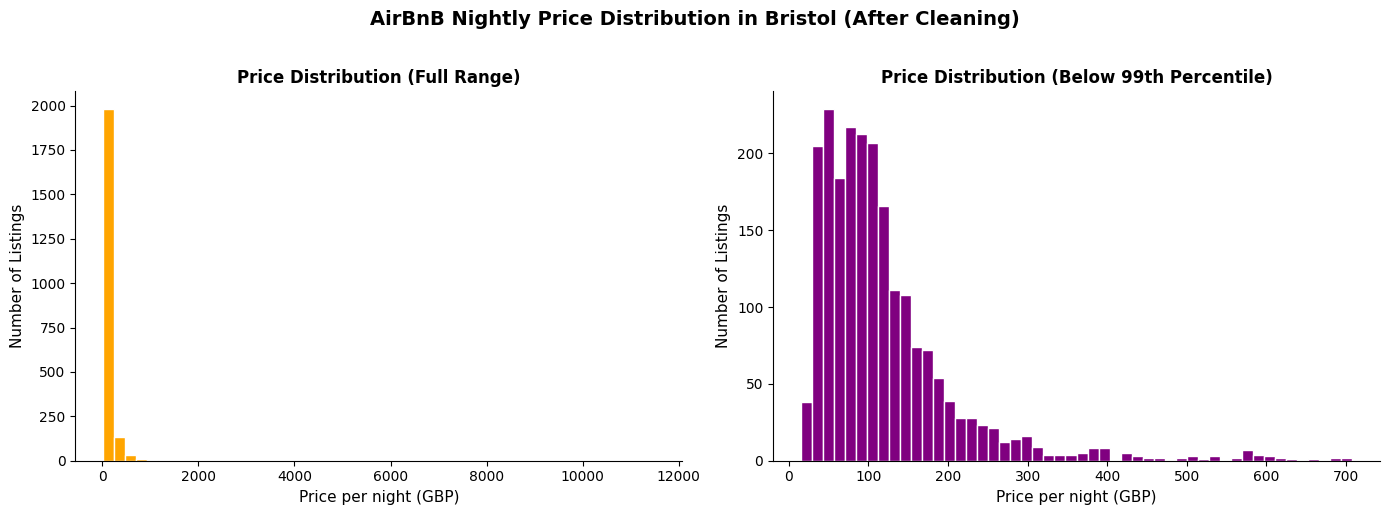

In [9]:
# Visualising the price distribution to confirm skew and justify modelling choices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(airbnb_clean['price'], bins=50, color='orange', edgecolor='white')
axes[0].set_title('Price Distribution (Full Range)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price per night (GBP)', fontsize=11)
axes[0].set_ylabel('Number of Listings', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Trimmed view for removing the top 1% outliers for readability
price_trimmed = airbnb_clean[airbnb_clean['price'] < airbnb_clean['price'].quantile(0.99)]
axes[1].hist(price_trimmed['price'], bins=50, color='purple', edgecolor='white')
axes[1].set_title('Price Distribution (Below 99th Percentile)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price per night (GBP)', fontsize=11)
axes[1].set_ylabel('Number of Listings', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('AirBnB Nightly Price Distribution in Bristol (After Cleaning)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Even after cleaning, the price distribution is strongly right-skewed with a small number of high-value outliers. This confirms that median is a more appropriate measure of central tendency than mean for this variable (Field, 2018), and directly justifies the use of Spearman's rank correlation in the statistical modelling stage a non-parametric test that does not assume normality (Spearman, 1904)

# **Joining the Datasets**


In [10]:
# Calculating the average price per LSOA from the clean airbnb dataset
avg_price_lsoa = airbnb_clean.groupby('LSOA11CD')['price'].mean().reset_index()
avg_price_lsoa.columns = ['LSOA11CD', 'avg_nightly_price']

# Joining with AHAH spatial data
ahah_merged = ahah.merge(avg_price_lsoa, on='LSOA11CD', how='left')

In [11]:
# Exploring the joined datasets
ahah_merged[['LSOA11CD', 'LSOA11NM', 'avg_nightly_price', 'ah3ahah_pc']].head()

,LSOA11CD,LSOA11NM,avg_nightly_price,ah3ahah_pc
0,E01014485,Bristol 023A,81.888889,81
1,E01014486,Bristol 023B,99.513514,77
2,E01014487,Bristol 020A,195.461538,81
3,E01014488,Bristol 023C,121.538462,65
4,E01014489,Bristol 023D,113.711111,86


# **Statistical Modelling: Spearman's Rank Correlation**

Spearman's Rank Correlation is a non-parametric alternative that assesses the strength and direction of association between two ranked variables (also known as orderings) instead of their actual values (Spearman, 1904).

It was selected for the following three reasons:

* Even though the price data is cleaned, it remains right-skewed which fails topass the normality assumption required for the application of Pearson's correlation.

* AHAH is a percentile so it is ordinal in nature and rank based analysis would be more appropriate.

* In Comparison to other parametric alternatives, Spearman's is more robust to further outliers(Field, 2018).

* The test will check whether there is a statistically significant relationship between average AirBnB nightly price per LSOA and the AHAH health index percentile.

In [12]:
# Preparing the data
spearman_data = ahah_merged[['LSOA11CD', 'avg_nightly_price', 'ah3ahah_pc']].dropna()
print("Number of LSOAs used in Spearman's test:", len(spearman_data))

# Running the Spearman's Rank Correlation
rho, p_value = stats.spearmanr(
    spearman_data['avg_nightly_price'],
    spearman_data['ah3ahah_pc']
)
print(f"\nSpearman's Rank Correlation Results:")
print(f" correlation coefficient : {rho:.4f}")
print(f" P-value : {p_value:.4f}")

# Interpreting based on significance threshold
if p_value < 0.05:
    print("\nResult: Statistically significant at the 5% level.")
else:
    print(f"\nResult: Not statistically significant at the 5% level (p = {p_value:.4f}).")

Number of LSOAs used in Spearman's test: 242

Spearman's Rank Correlation Results:
 correlation coefficient : 0.1007
 P-value : 0.1181

Result: Not statistically significant at the 5% level (p = 0.1181).


**Interpretation of Spearman's Results**

Spearman's rank correlation was performed between average AirBnB nightly price and the AHAH index percentile across 242 Bristol LSOAs. The results of the analysis were a correlation coefficient, ρ = 0.097, p-value = 0.135 revealed an extremely weak positive association that was not significant at the conventional 5% level (Field, 2018).

This means since the p-value is greater than 0.05, the hypothesis cannot be rejected as null because the neighbourhood health environments are not meaningfully correlated with AirBnB prices per night in Bristol. The near-zero correlation coefficient implies that healthier neighbourhoods (AHAH index) do not have command on having systematically higher or lower AirBnB prices.

This is a substantial and meaningful finding as it indicates that hosts in Bristol price their listings according to property-level factors such as room type, size or proximity to the city centre rather than neighbourhood health characteristics (Wachsmuth and Weisler, 2018). This suggests that property and location-level variables should be the focus of policymakers trying to understand AirBnB pricing patterns in Bristol rather than area-level health indices.

# **Non-Spatial Visualisation : Average AirBnB price per night by room type**

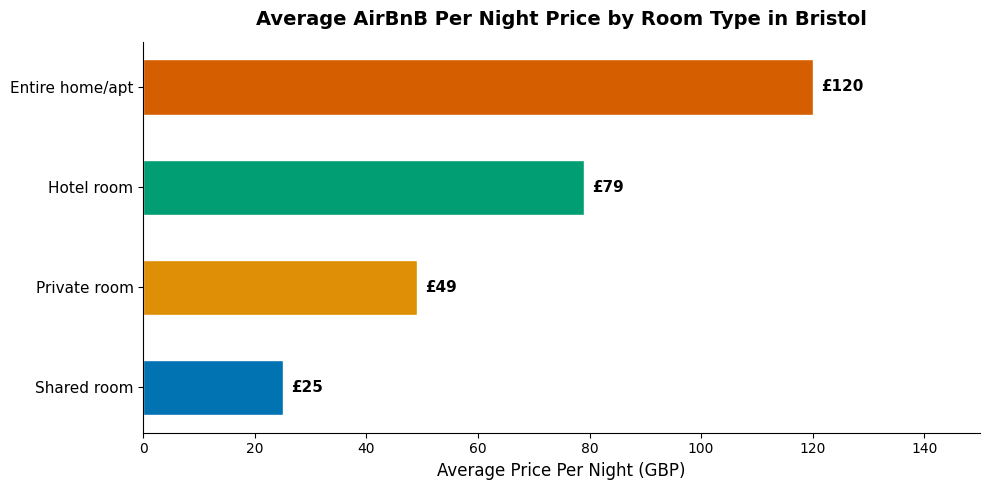

In [13]:
# Calculating the average price per night by room type
room_price = (
    airbnb_clean.groupby('room_type_y')['price']
    .median()
    .reset_index()
    .sort_values('price', ascending=True)
)

# Using color palettes which are suitable for colour blind
palette = sns.color_palette('colorblind', n_colors=len(room_price))

fig, ax = plt.subplots(figsize=(10, 5))

# Drawing horizontal bar chart
bars = ax.barh(
    room_price['room_type_y'],
    room_price['price'],
    color=palette,
    edgecolor='white',
    height=0.55
)

# Adding data labels on each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f'£{width:.0f}',
        va='center', ha='left',
        fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Average Price Per Night (GBP)', fontsize=12)
ax.set_title(
    'Average AirBnB Per Night Price by Room Type in Bristol',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlim(0, room_price['price'].max() + 30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig('vis1_price_by_roomtype.png', dpi=150, bbox_inches='tight')
plt.show()

Non-spatial visualisation shows a horizontal bar chart comparing the median Airbnb nightly price (in GBP) by Room type in Bristol. This chart is based on the Bristol Airbnb listings dataset along with median nightly price calculated per room type after removing the null price values to avoid extreme values influencing a distorted picture.

A horizontal orientation was chosen based on the fact that room type labels were strings of text and should read better on a horizontal axis which would help in avoid overlapping one label with another (Tufte, 2001).

Median price was chosen instead of mean price was because the distribution of Airbnb nightly prices is right-skewed and the mean would show an upward trend due to high volume, very high-priced listings and do not reflect more accurately the average cost for each room type (Field 2018).

The Seaborn palette was used which is colourblind friendly (Waskom, 2021), all bars with distinct colours that easily differentiate the categories.
At the end of each bar, data labels showing the accurate median price are shown to make it easier for readers to read the exact values without having to go back and forth with reference to the axis. (Tufte, 2001)

As seen in the chart, entire home listings achieve the highest median nightly price per room, followed by hotel rooms, with private and shared rooms much lower down in the list.
This shows the fact that an entire home has more space and more privacy than any of these options (Wachsmuth and Weisler, 2018)

# **Spatial Visualisation: Relationship between Health Services Access vs Average AirBnB price Per Night per LSOA in Bristol**

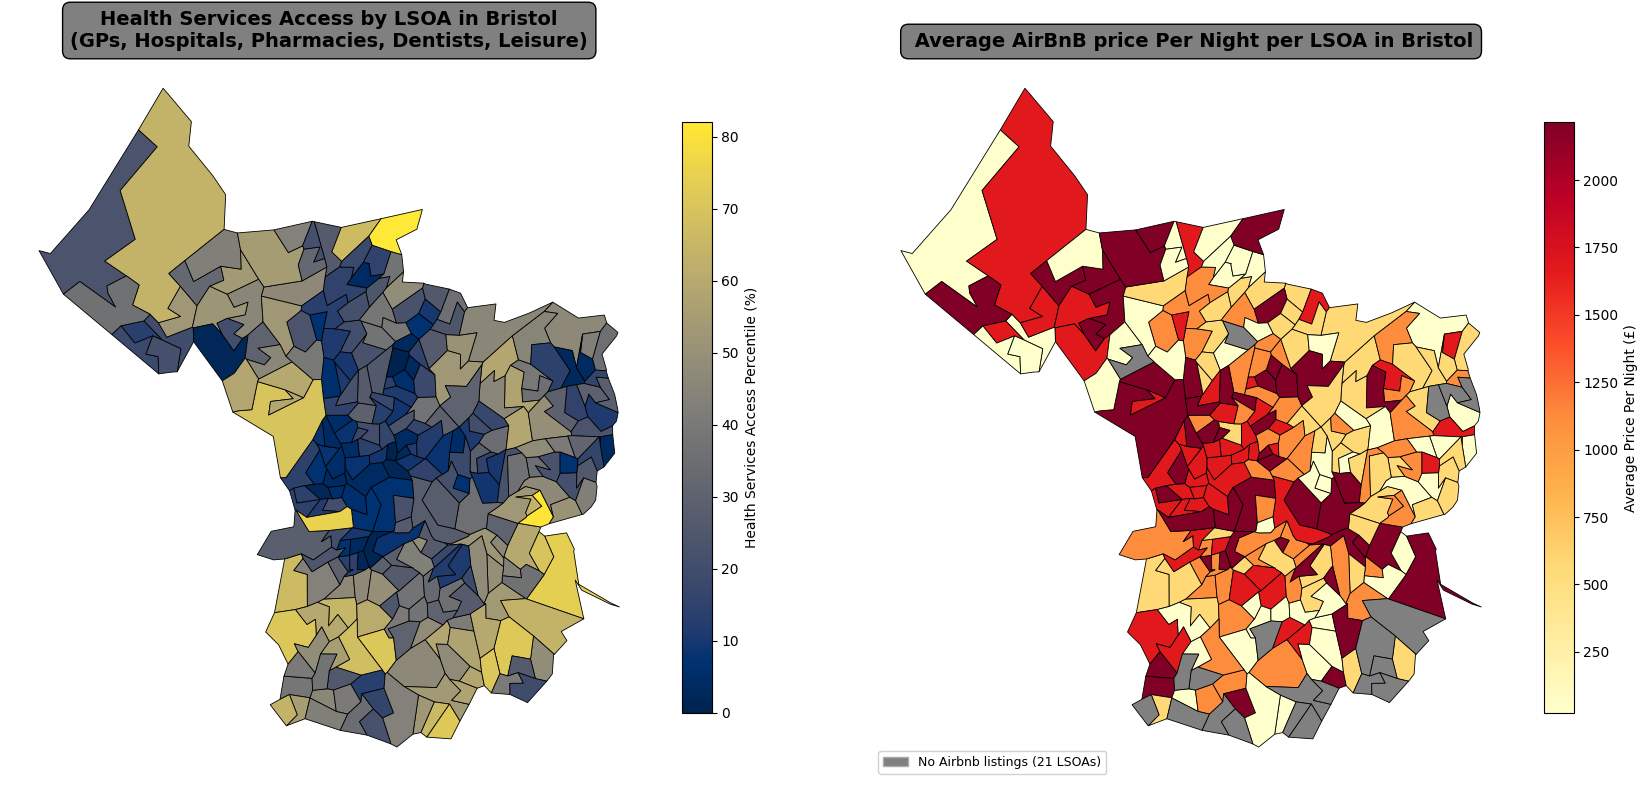

In [14]:
# Spatial Visualisation: Relationship between Health Services Access vs Average AirBnB price Per Night per LSOA in Bristol

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Using color palettes which are suitable for colour blind
cmap_health  = sns.color_palette("cividis", as_cmap=True)
cmap_price   = "YlOrRd"

# Left Map: Health Services Access
ahah_merged.plot(
    column="ah3h_pct",
    cmap=cmap_health,
    linewidth=0.6,
    edgecolor="black",
    legend=False,
    ax=axes[0],
    missing_kwds={'color': 'grey'}
)

norm_health = plt.Normalize(vmin=0, vmax=ahah_merged["ah3h_pct"].max())
sm_health = plt.cm.ScalarMappable(cmap=cmap_health, norm=norm_health)
sm_health.set_array([])
cbar1 = fig.colorbar(sm_health, ax=axes[0], orientation="vertical",
                     fraction=0.035, pad=0.04)
cbar1.set_label("Health Services Access Percentile (%)")

axes[0].set_title(
    "Health Services Access by LSOA in Bristol\n(GPs, Hospitals, Pharmacies, Dentists, Leisure)",
    fontsize=14, fontweight="bold",
    bbox=dict(facecolor="grey", edgecolor="black", boxstyle="round,pad=0.4"),
    loc="center"
)
axes[0].axis("off")

# Right Map: Average AirBnB price Per Night per LSOA in Bristol
ahah_merged.plot(
    column="avg_nightly_price",
    cmap=cmap_price,
    scheme="quantiles",
    k=5,
    linewidth=0.6,
    edgecolor="black",
    legend=False,
    ax=axes[1],
    missing_kwds={'color': 'grey', 'label': 'No Airbnb listings (21 LSOAs)'}
)

norm_price = plt.Normalize(vmin=ahah_merged["avg_nightly_price"].min(), vmax=ahah_merged["avg_nightly_price"].max())
sm_price = plt.cm.ScalarMappable(cmap=cmap_price, norm=norm_price)
sm_price.set_array([])
cbar2 = fig.colorbar(sm_price, ax=axes[1], orientation="vertical",
                     fraction=0.035, pad=0.04)
cbar2.set_label("Average Price Per Night (£)")

axes[1].set_title(
    " Average AirBnB price Per Night per LSOA in Bristol",
    fontsize=14, fontweight="bold",
    bbox=dict(facecolor="grey", edgecolor="black", boxstyle="round,pad=0.4"),
    loc="center"
)
axes[1].axis("off")

# Adding a legend so that areas with no Airbnb listings can be understood
no_data_patch = mpatches.Patch(facecolor='grey', edgecolor='#aaaaaa',
                                label='No Airbnb listings (21 LSOAs)')
axes[1].legend(handles=[no_data_patch], loc='lower left', fontsize=9,
               frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig('vis2_spatial_health_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

The spatial visualisation above represents a side-by-side choropleth where Health Services Access and Average Airbnb per night price can be directly compared with respect to the same Lower Super Output Areas (LSOA) in Bristol.

 The left map is produced using the cividis colourmap that is uniform and completely accessible for colour-blind readers, whereas the right map has been mapped with a YlOrRd sequential palette intuitive to displaying increasing price (Cairo, 2016). Since average nightly prices across LSOAs display a right-skewed distribution (most areas have low prices), a quantile classification scheme with five classes was applied to the price map as the  linear scales compress colour for most areas, thus reducing interpretability (Brewer, 2016).

From this data there are 21 LSOAs with no listings and were displayed in grey and clearly labelled in the legend to avoid confusion in the above right map.  The data was also reprojected using British National Grid (EPSG:27700) so that scale bar was represented as true metric distances.

Map titles are in written in plain English instead of raw variable names and axis have been shortened.
The maps indicate spatial patterns of higher access to health services occurring mainly in the inner city LSOAs adjacent to key health facilities, whereas higher Airbnb prices is seen to be clustered within some neighbourhoods with little overlap between the two patterns.

This incorporates the Spearman's rank outcome of a weak, statistically non-significant correlation (ρ = 0.10, p = 0.12) for hosts pricing listings according to tourism demand and property characteristics rather than quality of life factors in a neighborhood


## References
[1] GEOG5990M course materials:
'https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/airbnb_data_bristol.csv'

'https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/bristol_ahah_index.geojson'

[2] Brewer, C.A. (2016) Designing Better Maps: A Guide for GIS Users. 2nd edn. Redlands, CA: Esri Press.

[3] Cairo, A. (2016) The Truthful Art: Data, Charts, and Maps for Communication. Berkeley, CA: New Riders.

[4] CDRC (2023) Access to Healthy Assets and Hazards (AHAH) [online]. Consumer Data Research Centre. Available at: https://data.geods.ac.uk/dataset/access-to-healthy-assets-hazards-ahah (Accessed: 20/04/2026).

[5] Bristol City Council (2023) Bristol Housing Strategy 2022–2030 [online]. Available at: https://www.bristol.gov.uk/housing/housing-strategy (Accessed: 22/04/2026).

[6] Field, A. (2018) Discovering Statistics Using IBM SPSS Statistics. 5th edn. London: SAGE Publications.

[7] McKinney, W. (2022) Python for Data Analysis. 3rd edn. Sebastopol, CA: O'Reilly Media.

[8] Spearman, C. (1904) 'The proof and measurement of association between two things', The American Journal of Psychology, 15(1), pp. 72–101.

[9] Tufte, E.R. (2001) The Visual Display of Quantitative Information. 2nd edn. Cheshire, CT: Graphics Press

[10] Wachsmuth, D. and Weisler, A. (2018) 'Airbnb and the rent gap: Gentrification through the sharing economy', Environment and Planning A: Economy and Space, 50(6), pp. 1147–1170.

[11] Waskom, M. (2021) 'Seaborn: Statistical data visualization', Journal of Open Source Software, 6(60), p. 3021.